In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from newspaper import Article
from tqdm import tqdm
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, OrdinalEncoder, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from IPython.display import display, clear_output
data = pd.read_csv('data_visualization.csv')

The goal of this file is to do a first pass on visualization and dashboard creation. My goal for this week is to build a nice widget that shows my ticker clustering, allows the user to select a ticker and then view all the authors that have written about that ticker and certain stats such as articles written, accuracy, sentiment and more.

In [2]:
ticker_features = data.groupby('ticker').agg(
    avg_sentiment=('sentiment_encoded', 'mean'),
    sentiment_std=('sentiment_encoded', 'std'),
    bullish_rate=('sentiment_encoded', lambda x: (x == 1).mean()),
    bearish_rate=('sentiment_encoded', lambda x: (x == -1).mean()),
    avg_return_30d=('return_30d', 'mean'),
    avg_return_6m=('return_6m', 'mean'),
    vol_30d=('return_30d', 'std'),
    article_count=('headline', 'count'),
    long_term_ratio=('long_term', 'mean')
).reset_index()
ticker_features['sentiment_std'] = ticker_features['sentiment_std'].fillna(0)
ticker_features['vol_30d'] = ticker_features['vol_30d'].fillna(0)
ticker_features['log_article_count'] = np.log1p(ticker_features['article_count'])

In [3]:
cluster_cols = [
    'avg_sentiment',
    'avg_return_30d',
    'avg_return_6m',
    'vol_30d',
    'long_term_ratio',
    'log_article_count'
]

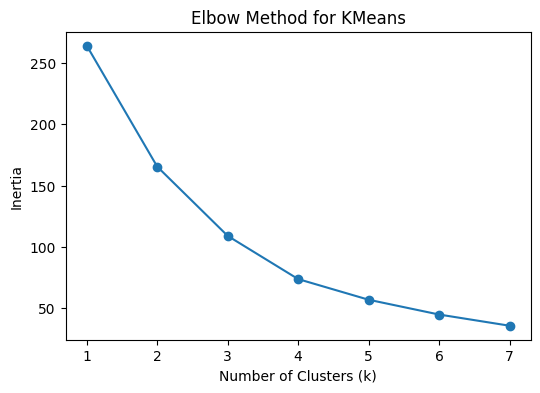

In [4]:
X = ticker_features[cluster_cols]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
inertia = []

for k in range(1, 8):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1, 8), inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for KMeans")
plt.show()

In [5]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
ticker_features['cluster'] = kmeans.fit_predict(X_scaled)

In [6]:
score = silhouette_score(X_scaled, ticker_features['cluster'])
print("Silhouette score:", round(score, 3))

Silhouette score: 0.291


In [7]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

ticker_features['pca1'] = X_pca[:, 0]
ticker_features['pca2'] = X_pca[:, 1]

In [8]:
print("PCA explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained:", pca.explained_variance_ratio_.sum())

PCA explained variance ratio: [0.45528695 0.24455384]
Total explained: 0.6998407968950906


In [9]:
cluster_summary = ticker_features.groupby('cluster')[[
    'avg_sentiment',
    'avg_return_30d',
    'avg_return_6m',
    'vol_30d',
    'article_count',
    'long_term_ratio'
]].mean()

print(cluster_summary)

         avg_sentiment  avg_return_30d  avg_return_6m   vol_30d  \
cluster                                                           
0            -0.012244        0.013657       0.110537  0.075926   
1            -0.065217        0.187762       1.791052  0.340094   
2            -0.081380        0.009921       0.087416  0.113344   
3             0.000000       -0.073287      -0.184558  0.000000   

         article_count  long_term_ratio  
cluster                                  
0           540.269231         0.105554  
1           414.000000         0.036232  
2           590.375000         0.094436  
3             1.000000         0.000000  


I want to talk more about clustering in our meeting for tickers but regardless of what the final clusters end of being the same idea for the dashboard still exists so im going to move forward for now because im spending too much time on the best way to cluster the tickers. Note I am using llms to setup for widgets and dashboard display after detailing exactly what I want in terms of features and results.

In [10]:
print(ticker_features['cluster'].value_counts().sort_index())

cluster
0    26
1     1
2    16
3     1
Name: count, dtype: int64


In [11]:
cluster_descriptions = {
    0: "Stable, heavily covered stocks with moderate returns and relatively steady behavior.",
    1: "Higher-growth, higher-volatility stocks with stronger price movement after news coverage.",
    2: "well-covered stocks with quieter behavior.",
    3: "Neutral sentiment stocks with negative returns."
}

In [12]:
publisher_overall = data.groupby('publisher').agg(
    overall_articles=('headline', 'count'),
    overall_accuracy=('accuracy', 'mean'),
    overall_avg_sentiment=('sentiment_encoded', 'mean'),
    overall_long_term_ratio=('long_term', 'mean')
).reset_index()

In [13]:
publisher_by_ticker = data.groupby(['ticker', 'publisher']).agg(
    ticker_articles=('headline', 'count'),
    ticker_accuracy=('accuracy', 'mean'),
    ticker_avg_sentiment=('sentiment_encoded', 'mean'),
    ticker_long_term_ratio=('long_term', 'mean')
).reset_index()

In [14]:
publisher_lookup = publisher_by_ticker.merge(
    publisher_overall,
    on='publisher',
    how='left'
)

In [15]:
publisher_lookup.head()

,ticker,publisher,ticker_articles,ticker_accuracy,ticker_avg_sentiment,ticker_long_term_ratio,overall_articles,overall_accuracy,overall_avg_sentiment,overall_long_term_ratio
0,ADBE,Alex Furno,1,0.000000,-1.000000,0.000000,29,0.517241,-0.103448,0.206897
1,ADBE,Allie Wickman,1,0.000000,0.000000,0.000000,130,0.615385,0.015385,0.069231
2,ADBE,Benzinga Newsdesk,32,0.406250,0.000000,0.000000,2031,0.500739,-0.006401,0.012309
3,ADBE,Benzinga Staff,14,0.571429,-0.285714,0.214286,176,0.539773,-0.096591,0.153409
4,ADBE,Benzinga Staff 5,1,1.000000,0.000000,0.000000,101,0.574257,-0.108911,0.069307


In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
ticker_dropdown = widgets.Dropdown(
    options=sorted(ticker_features['ticker'].unique()),
    description='Ticker:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='300px')
)

In [17]:
output = widgets.Output()

In [18]:
def update_dashboard(change=None):
    selected_ticker = ticker_dropdown.value
    
    with output:
        clear_output(wait=True)
        
        # -----------------------------
        # 1. Selected ticker summary
        # -----------------------------
        selected_row = ticker_features[ticker_features['ticker'] == selected_ticker].iloc[0]
        
        cluster_num = int(selected_row['cluster'])
        cluster_desc = cluster_descriptions.get(cluster_num, "No description available.")
        
        print("=" * 70)
        print(f"Ticker: {selected_ticker}")
        print(f"Cluster: {cluster_num}")
        print(f"Cluster Description: {cluster_desc}")
        print("-" * 70)
        print(f"Average Sentiment:   {selected_row['avg_sentiment']:.3f}")
        print(f"Average 30d Return:  {selected_row['avg_return_30d']:.3f}")
        print(f"Average 6m Return:   {selected_row['avg_return_6m']:.3f}")
        print(f"30d Volatility:      {selected_row['vol_30d']:.3f}")
        print(f"Article Count:       {int(selected_row['article_count'])}")
        print(f"Long-Term Ratio:     {selected_row['long_term_ratio']:.3f}")
        print("=" * 70)
        
        print("\n")
        
        # -----------------------------
        # 2. PCA cluster plot
        # -----------------------------
        plt.figure(figsize=(8, 5))
        
        plt.scatter(
            ticker_features['pca1'],
            ticker_features['pca2'],
            c=ticker_features['cluster'],
            alpha=0.7
        )
        
        plt.scatter(
            selected_row['pca1'],
            selected_row['pca2'],
            s=220,
            marker='*'
        )
        
        plt.xlabel("PCA Component 1")
        plt.ylabel("PCA Component 2")
        plt.title("Ticker Clusters (PCA Projection)")
        plt.show()
        
        # -----------------------------
        # 3. Sentiment vs Return plot
        # -----------------------------
        plt.figure(figsize=(8, 5))
        
        plt.scatter(
            ticker_features['avg_sentiment'],
            ticker_features['avg_return_30d'],
            c=ticker_features['cluster'],
            alpha=0.7
        )
        
        plt.scatter(
            selected_row['avg_sentiment'],
            selected_row['avg_return_30d'],
            s=220,
            marker='*'
        )
        
        plt.xlabel("Average Sentiment")
        plt.ylabel("Average 30d Return")
        plt.title("Ticker Clusters (Sentiment vs Return)")
        plt.show()
        
        # -----------------------------
        # 4. Publisher table
        # -----------------------------
        selected_publishers = publisher_lookup[
            publisher_lookup['ticker'] == selected_ticker
        ].copy()
        
        selected_publishers = selected_publishers.sort_values(
            by='ticker_articles',
            ascending=False
        )
        
        selected_publishers = selected_publishers[[
            'publisher',
            'ticker_articles',
            'overall_articles',
            'overall_accuracy',
            'ticker_accuracy',
            'ticker_avg_sentiment',
            'overall_avg_sentiment',
            'ticker_long_term_ratio'
        ]].rename(columns={
            'publisher': 'Publisher',
            'ticker_articles': 'Articles on Ticker',
            'overall_articles': 'Overall Articles',
            'overall_accuracy': 'Overall Accuracy',
            'ticker_accuracy': 'Ticker Accuracy',
            'ticker_avg_sentiment': 'Avg Sentiment on Ticker',
            'overall_avg_sentiment': 'Overall Avg Sentiment',
            'ticker_long_term_ratio': 'Long-Term Ratio on Ticker'
        })
        
        print("Publishers Who Wrote About This Ticker")
        display(selected_publishers.reset_index(drop=True))

In [19]:
ticker_dropdown.observe(update_dashboard, names='value')

Below is a very rough draft of the dashboard that includes a ticker drop down where the user can select which ticker they are interested in. After selection you will see information about the ticker including descriptions about the articles that focused on the ticker such as 30d volatility of the ticker, the average returns of the ticker after articles were published, the average sentiment of the ticker which I think is the most interesting so you can see if the publishers are bullish or bearish.

You will then see ticker clustering in the sentiment vs return. The PCA project is not labeled because I still want to discuss with you the best ways to display this when I use many features to cluster the tickers. The most important component of the dashboard for me is that you will see a list of authors that have written about the ticker you have selected and relevant information about their articles such as how much they write about the ticker, how accurate they are, and their sentiment.

In [20]:
display(ticker_dropdown, output)
update_dashboard()

Dropdown(description='Ticker:', layout=Layout(width='300px'), options=('ADBE', 'AIG', 'AMD', 'AVGO', 'AXP', 'A…

Output()

I am running out of time this week but I really like the direction this is going. After finalizing how to cluster the tickers properly I think smoothing the dashboard, perhaps adding profile pictures of the authors and making it more dynamic would be great for the final result.